In [13]:
pip install requests beautifulsoup4 pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [14]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [15]:
# Scrape Book Data (GBP only)


def scrape_books(url, limit=20):
    books = []

    response = requests.get(url, timeout=10)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    items = soup.select("article.product_pod")[:limit]

    for item in items:
        title = item.h3.a["title"]
        price_text = item.select_one(".price_color").text

        price_gbp = float(
            price_text.replace("£", "")
                      .replace("Â", "")
                      .strip()
        )

        books.append({
            "Title": title,
            "Price_GBP": price_gbp
        })

    return books


In [16]:
# Currency Conversion (Assignment API)

def convert_currency(amount, from_currency, to_currency):
    
    url = "https://api.exchangerate.host/convert"

    params = {
        "access_key": "YOUR_API_KEY",  # Assignment placeholder
        "from": from_currency,
        "to": to_currency,
        "amount": amount
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        if data.get("success") is True and data.get("result") is not None:
            return data["result"]
        else:
            return None

    except requests.exceptions.RequestException:
        return None




Scraped & Converted Prices:
                                                                                         Title  Price_GBP  Price_KES                Conversion_Status     Conversion_Time
                                                                          A Light in the Attic      51.77    9059.75 Fallback used (API key required) 2026-04-15 07:57:49
                                                                            Tipping the Velvet      53.74    9404.50 Fallback used (API key required) 2026-04-15 07:57:49
                                                                                    Soumission      50.10    8767.50 Fallback used (API key required) 2026-04-15 07:57:49
                                                                                 Sharp Objects      47.82    8368.50 Fallback used (API key required) 2026-04-15 07:57:49
                                                         Sapiens: A Brief History of Humankind      54.23    9490.25 Fall

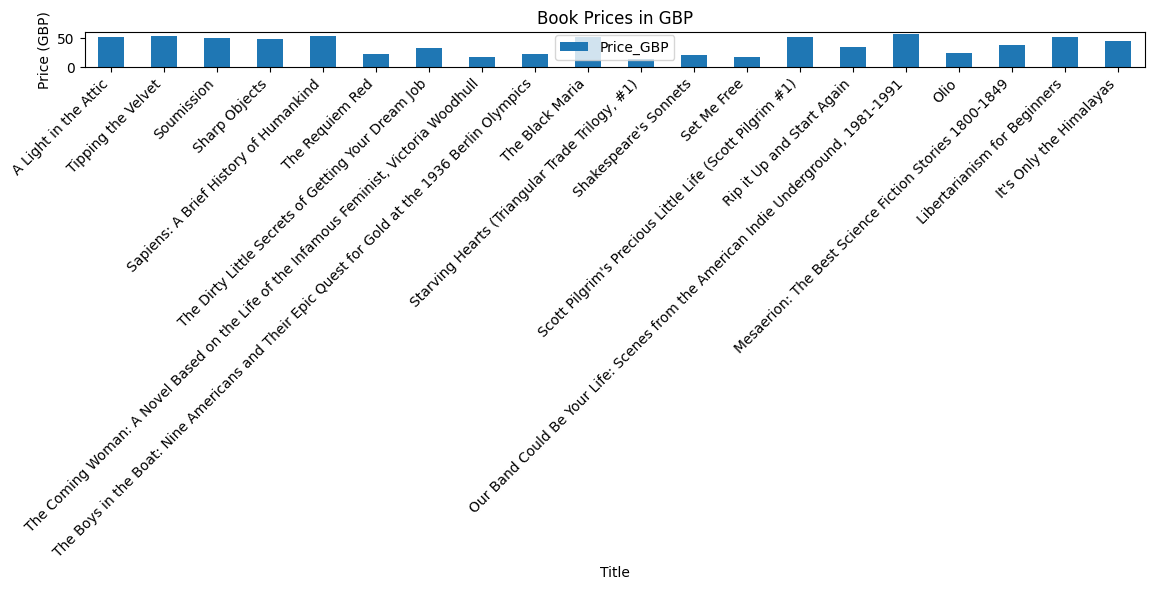

In [17]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime



# Scrape Book Data (GBP only)


def scrape_books(url, limit=20):
    books = []

    response = requests.get(url, timeout=10)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    items = soup.select("article.product_pod")[:limit]

    for item in items:
        title = item.h3.a["title"]
        price_text = item.select_one(".price_color").text

        price_gbp = float(
            price_text.replace("£", "")
                      .replace("Â", "")
                      .strip()
        )

        books.append({
            "Title": title,
            "Price_GBP": price_gbp
        })

    return books



# Currency Conversion (Assignment API)

def convert_currency(amount, from_currency, to_currency):
    
    url = "https://api.exchangerate.host/convert"

    params = {
        "access_key": "YOUR_API_KEY",  # Assignment placeholder
        "from": from_currency,
        "to": to_currency,
        "amount": amount
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        if data.get("success") is True and data.get("result") is not None:
            return data["result"]
        else:
            return None

    except requests.exceptions.RequestException:
        return None



# Main Program Logic

SOURCE_URL = "https://books.toscrape.com/"
FROM_CURRENCY = "GBP"
TO_CURRENCY = "KES"
FALLBACK_RATE = 175

# Scrape data
books = scrape_books(SOURCE_URL, limit=20)

# Convert prices
for book in books:
    converted = convert_currency(
        book["Price_GBP"],
        FROM_CURRENCY,
        TO_CURRENCY
    )

    if converted is None:
        book["Price_KES"] = round(book["Price_GBP"] * FALLBACK_RATE, 2)
        book["Conversion_Status"] = "Fallback used (API key required)"
    else:
        book["Price_KES"] = round(converted, 2)
        book["Conversion_Status"] = "Live API conversion"

# Create DataFrame
df = pd.DataFrame(books)
df["Conversion_Time"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Display results
print("\nScraped & Converted Prices:")
print(df.to_string(index=False))

# Save output files
df.to_csv("book_prices_converted.csv", index=False)
df.to_json("book_prices_converted.json", orient="records", indent=4)


# Plot

df.plot(
    x="Title",
    y="Price_GBP",
    kind="bar",
    figsize=(12, 6),
    title="Book Prices in GBP"
)

plt.ylabel("Price (GBP)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
